# GFCP 2022
* https://doi.org/10.1371/journal.pcbi.1010492
* https://github.com/pachterlab/GFCP_2022/blob/main/notebooks/abcd_sim.ipynb

## Setup

In [1]:
using GLMakie, LinearAlgebra, ddHodge
using StatsBase: mean, quantile

### Set graphic theme

In [2]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
    lc = :black
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
    lc = :white
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Load data

In [3]:
import Muon
h5file = "../data/simdata_abcd_2000_100.h5ad"
adata = Muon.readh5ad(h5file,backed=false)

AnnData object 2000 ✕ 100

In [4]:
# Check that the definition of the velocity: ds/dt = βu - γs, is correct
let
    bU = adata.layers["unspliced"]*diagm(adata.var.beta)
    gS = adata.layers["spliced"]*diagm(adata.var.gamma)
    norm(adata.layers["velocity"] - (bU - gS))
end

0.0

## Run ddHodge

In [14]:
# Reconstruction on ** log-transformed data **
import CUDA
X = adata.layers["spliced"]'
V = adata.layers["velocity"]'
fdim, N = size(X)
npc = fdim # no dimension reduction
logX0 = log.(X .+ 1) # logX(t)
logX1 = log.(clamp.(X+V, 0, Inf) .+ 1) # logX(t+1)
mu0 = mean(logX0, dims=2)
# centered but not scaled (according to sklern PCA)
sv = svd(logX0 .- mu0)
loadings = sv.U[:,1:npc]
Xr = sv.V[:,1:npc]'
Vr = loadings'*(logX1 .- mu0) - Xr # projection
pts = Point2f.(eachcol(Xr[1:2,:]))
#import UMAP; umap = UMAP.umap(X_pca)
g, kdtree = kNNGraph(Xr, 16)
ddh = ddHodgeWorkflow(g, Xr, Vr, rdim=4, λ=1.0, useCUDA=true, ssa=true)

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.192 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.5363597246127366
[ Info: ... done in 3.821 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.283 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.5321285140562249
[ Info: ... done in 0.475 sec.


:::ddHodge::: values over graph {2000, 27888}, dimensions: 100 -> 4 (ssa: on)

Note:
* The projected dynamics of RNA-velocity model have a constant negative divergence: $-\sum{\gamma_i}$.
* RNA-velocity dynamics occurs in the space with the dimension of $2 \times$ num. genes (the pair of $u_i$ and $s_i$).
* We expect that the **projected** velocity $ds/dt$ approximates a true (unknown) genes' dynamics.

In [6]:
extrema(tr.(ddh.J)), sum(-adata.var.gamma)

((-27.205757680026053, -13.818794350537855), -342.74115878342894)

## Plots

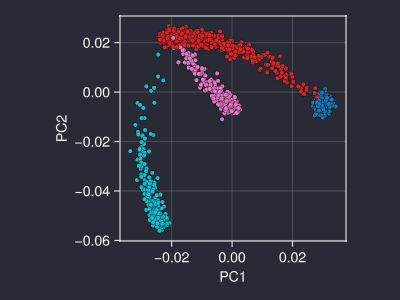

In [7]:
let vals = adata.obs.celltype, cmap=:tab10
    fig = Figure(size=(400,300))
    ax = Axis(fig[1,1],xlabel="PC1",ylabel="PC2",aspect=1)
    sc = scatter!(
        pts,color=vals, colormap=cmap, rasterize=2,
        markersize=6,strokecolor=:black,strokewidth=0.3
    )
    #Colorbar(fig[1,2],sc,height=Relative(0.6),label="Time")
    fig
end

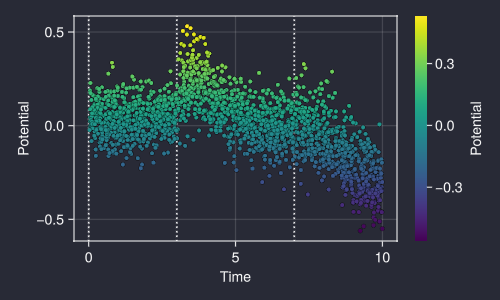

In [8]:
let cmap = :viridis, ms=6
    vals = ddh.u #ddh.div
    #vals = adata.obs.celltype
    y = ddh.u #Xr[1,:]
    vmax = quantile(abs.(vals),0.95)
    crange = cmap == :coolwarm ? (-vmax,vmax) : extrema(vals)
    fig = Figure(size=(500,300))
    #ax = Axis(fig[1,1],xlabel="Time",ylabel="PC1")
    ax = Axis(fig[1,1],xlabel="Time",ylabel="Potential")
    vlines!([0,3,7],linestyle=:dot,color=lc)
    sc = scatter!(adata.obs.time, y,
        markersize=ms, color=vals, rasterize=2,
        colormap=cmap, colorrange=crange,
        strokecolor=:black, strokewidth=0.3
    )
    Colorbar(fig[1,2],sc,label="Potential")
    fig
end

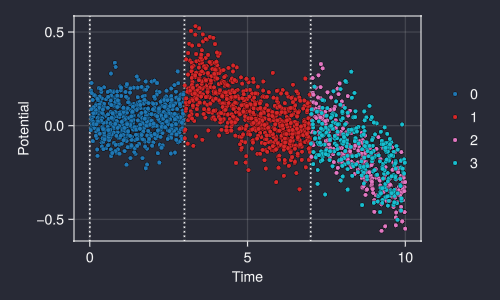

In [9]:
let cmap = :tab10, ms=6
    cts = sort(unique(adata.obs.celltype))
    pal = Dict(cts .=> resample_cmap(:tab10, 4)[1:length(cts)])
    vals = adata.obs.celltype
    y = ddh.u #ddh.div
    fig = Figure(size=(500,300))
    #ax = Axis(fig[1,1],xlabel="Time",ylabel="PC1")
    ax = Axis(fig[1,1],xlabel="Time",ylabel="Potential")
    vlines!([0,3,7],linestyle=:dot,color=lc)
    for ct in cts
        inds = findall(vals .== ct)
        scatter!(adata.obs.time[inds], y[inds],
            markersize=ms, color=pal[ct], colormap=cmap,
            strokecolor=:black,strokewidth=0.3, #alpha=0.6,
            label=string(ct), rasterize=2,
        )
    end
    Legend(fig[1,2],ax,orientation=:vertical)
    fig
end

## Check the trajectory of $\mu$ in Poisson sampling

In [10]:
# Lunge-Kutta 4: returns s+1 point of the trajectory
function kutta(f::Function, x0::Vector{Float64}; s=100::Int, dt=0.01::Float64)
    X = zeros(Float64,length(x0),s+1) # +1 is required for t=0
    X[:,1] = x0
    for i in 1:s
        k1 = f(X[:,i])dt
        k2 = f(X[:,i] + k1/2)dt
        k3 = f(X[:,i] + k2/2)dt
        k4 = f(X[:,i] + k3)dt
        X[:,i+1] = X[:,i] + (k1 + 2k2 + 2k3 + k4)/6
    end
    return X
end

kutta (generic function with 1 method)

In [11]:
f = let 
    B = diagm(adata.var.beta)
    G = diagm(adata.var.gamma)
    R = [-B zeros(fdim, fdim); B -G]
    (x;a) -> R*x + [a; zeros(fdim)]
end

# alphas (transcription rates)
A = [adata.var.k0 adata.var.k1 adata.var.k2 adata.var.k3]

utraj, straj = let dt = 0.01
    checkpts = [0,3,7,10]
    steps = Int.(diff(checkpts)/dt)
    # steady state of u and s at t=0
    traj = [A[:,1]./adata.var.beta; A[:,1]./adata.var.gamma]
    for i in 1:length(steps)
        traj = [traj kutta(x -> f(x;a=A[:,i]), traj[:,end]; s=steps[i], dt=dt)[:,2:end]]
    end 
    traj[1:fdim,:], traj[fdim+1:end,:]
end

([0.012835305346235464 0.012835305346235464 … 0.9486333157080684 0.9486333157080684; 0.0045118794938573984 0.0045118794938573984 … 0.07386730766471168 0.07386730766471168; … ; 11.20110716551186 11.20110716551186 … 0.2920159913037536 0.29201599132197054; 0.004219828884705124 0.004219828884705124 … 0.6015882234986635 0.6015882234986635], [0.051733909930235716 0.051733909930235716 … 3.8235012327248206 3.8235032759616616; 0.053074520963323796 0.053074520963323796 … 1.1758530565479746 1.1726770750923625; … ; 17.885221227155892 17.885221227155892 … 0.46627105924753687 0.466271124474318; 0.017046932562582745 0.017046932562582745 … 2.4301042354294355 2.4301089441469785])

A[i, :] / adata.var.gamma[i] = [0.053074520963323796, 7.278540758789371, 0.8689221364383664, 11.758706353131046]
straj[i, end] = 1.1726770750923625


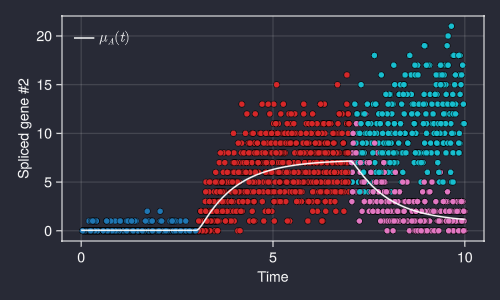

In [12]:
let i = 2 #16
    @show A[i,:]/adata.var.gamma[i] # steady states
    @show straj[i,end]
    tl = LinRange(0,10,size(straj,2))
    fig = Figure(size=(500,300))
    ax = Axis(fig[1,1],xlabel="Time",ylabel="Spliced gene #$(i)")
    scatter!(
        adata.obs.time, X[i,:], markersize=8, rasterize=2,
        strokewidth=0.5, strokecolor=:black, #alpha=0.6,
        color=adata.obs.celltype, colormap=:tab10
    )
    lines!(tl,straj[i,:],color=lc,label=L"\mu_A(t)")
    axislegend(position=:lt)
    fig
end

## Compatibility of the invariant subspace and reduced dimension

* $J_R$: the reconstructed Jacobian  in a dimension reduced space $R \subset W$
* $S$: the invariant subspace $JS \subseteq S$ of the true Jacobian in the full dimensional space $W$

When $R$ is invariant under $J$, i.e., $JR \subseteq R$, the eigenvalues of $J_R$ have a subset of $J$'s eigenvalues.

(We just expect that the dimension reduced space is close to an invariant subspace of $J$.)

The topic of the lower dimensional approximation of eigenvalue problem is related to the **Rayleigh-Ritz method** in numerical linear algebra.

In [15]:
# Full dynamics of (u,s) represented by 4 x 4 matrix of 2 genes
pair = [1,3]
ddhr, Jr = let N=100, d=2
    subs = sortperm(vec(mapslices(maximum,X,dims=2)),rev=true)[1:d]
    W = [i==j for i in 1:2d, j in pair] # basis of the reduced space
    B = diagm(adata.var.beta[subs])
    G = diagm(adata.var.gamma[subs])
    J = [-B zeros(d, d); B -G] # true J
    @show rank([J*W W]) # 2 if span(JW) = span(W)
    f = (x;a) -> J*x + [a; zeros(d)]
    Xr = stack(randn(2d,N))
    Vr = stack([f(Xr[:,i];a=A[subs,1]) for i in 1:N])
    gr, = kNNGraph(Xr[d+1:end,:], 16)
    # reconstruction will success if one keep the (u,s) pair
    ddh = ddHodgeWorkflow(gr, Xr[pair,:], Vr[pair,:], ssa=false)
    ddh, J
end
display(Jr)
@show mean(abs2.(ddhr.div .- tr(Jr[pair,pair]))) # MSE of div.
round.(ddhr.J[1],digits=4) # the section of J

rank([J * W W]) = 2


[ Info: (1/4) Potential estimation
[ Info: ... done in 0.001 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.0 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.002 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 0.003 sec.


4×4 Matrix{Float64}:
 -14.6634  -0.0       0.0       0.0
  -0.0     -9.03918   0.0       0.0
  14.6634   0.0      -1.64182  -0.0
   0.0      9.03918  -0.0      -1.64043

mean(abs2.(ddhr.div .- tr(Jr[pair, pair]))) = 4.836949042343423e-22


2×2 Matrix{Float64}:
 -14.6634   0.0
  14.6634  -1.6418